# Importância das features

**Etapa:** interpretação de Random Forest e PLS

Comparamos importância nativa, coeficientes padronizados, VIP Scores e permutation importance.

**Entrada:** importâncias e coeficientes congelados do teste final  
**Resultado principal:** GOLD_PRICE e seus lags concentram a maior contribuição preditiva


## 1. Importações, caminhos e funções

In [1]:
from pathlib import Path
import hashlib, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
from IPython.display import display

warnings.filterwarnings("ignore")
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "bases/grupo5/gold_daily_modeling.csv").exists())
BASE_PATH = ROOT / "bases/grupo5/gold_daily_modeling.csv"
OUT = ROOT / "analyses/grupo5/outputs"
OUT.mkdir(parents=True, exist_ok=True)
PROTOCOL_PATH = OUT / "protocol.json"
SEED = 42
np.random.seed(SEED)

def sha256(path):
    return hashlib.sha256(path.read_bytes()).hexdigest()

def load_data():
    df = pd.read_csv(BASE_PATH, parse_dates=["DATE"]).sort_values("DATE").reset_index(drop=True)
    raw_path = ROOT / "bases/grupo5-tratamento/gold_daily_prices.csv"
    raw = pd.read_csv(raw_path, sep=None, engine="python", parse_dates=["DATE"])
    raw["EXPECTED_TARGET"] = pd.to_numeric(raw["VALUE"], errors="coerce").shift(-1)
    raw["TARGET_DATE"] = raw["DATE"].shift(-1)
    target_lookup = raw[["DATE", "TARGET_DATE", "EXPECTED_TARGET"]]
    df = df.merge(target_lookup, on="DATE", how="left", validate="one_to_one")
    assert df["DATE"].is_monotonic_increasing and not df["DATE"].duplicated().any()
    assert "TARGET_UP" not in df.columns and not df.isna().any().any()
    assert np.allclose(df["TARGET"], df["EXPECTED_TARGET"])
    return df.drop(columns="EXPECTED_TARGET")



In [2]:
def load_protocol(require_data_decisions=False):
    if not PROTOCOL_PATH.exists():
        raise RuntimeError("DECISÃO NECESSÁRIA: execute 01_documentacao_bases.ipynb primeiro.")
    protocol = json.loads(PROTOCOL_PATH.read_text(encoding="utf-8"))
    if protocol.get("protocol_version") != 2:
        raise RuntimeError("Protocolo desatualizado: execute novamente 01_documentacao_bases.ipynb.")
    if protocol["dataset_sha256"] != sha256(BASE_PATH):
        raise RuntimeError("A base congelada não corresponde ao hash do protocolo.")
    if require_data_decisions:
        missing = [k for k in ("source", "unit", "cleaning", "features", "seasonal_period") if not protocol["decisions"].get(k)]
        if missing:
            raise RuntimeError(f"DECISÃO NECESSÁRIA: complete as decisões {missing} antes de modelar.")
    return protocol

def save_protocol(protocol):
    PROTOCOL_PATH.write_text(json.dumps(protocol, indent=2, ensure_ascii=False), encoding="utf-8")

def origins(protocol, split):
    return protocol["origins"][split]

def target_dates(df, origin_ids):
    return df["TARGET_DATE"].iloc[origin_ids].to_numpy()


## 2. Importâncias de RF e PLS

,dataset,model,feature,native_importance,standardized_coefficient,vip_score,permutation_mean,permutation_std,split,is_external,permutation_rank
0,gold,PLS_Regression,GOLD_PRICE,140.207141,140.207141,1.500274,347.965386,13.465087,test_final_post_selection,False,1
1,gold,PLS_Regression,GOLD_LAG_1,15.968976,15.968976,1.499292,30.900907,1.403302,test_final_post_selection,False,2
2,gold,PLS_Regression,GOLD_ROLLING_MEAN_5,4.621253,-4.621253,1.497909,5.326437,0.399291,test_final_post_selection,False,3
3,gold,PLS_Regression,GOLD_LAG_5,2.383091,2.383091,1.495768,1.468209,0.210502,test_final_post_selection,False,4
4,gold,PLS_Regression,GOLD_LAG_20,1.788625,-1.788625,1.485496,0.978443,0.150097,test_final_post_selection,False,5
5,gold,PLS_Regression,GOLD_ROLLING_STD_5,0.193893,-0.193893,0.774728,0.014091,0.020936,test_final_post_selection,False,6
6,gold,PLS_Regression,TREASURY_10Y,0.135387,-0.135387,0.343462,0.001584,0.001232,test_final_post_selection,True,7
7,gold,PLS_Regression,MONTH_COS,0.024944,0.024944,0.087602,0.000542,0.001137,test_final_post_selection,False,8
8,gold,PLS_Regression,MONTH_SIN,0.020840,-0.020840,0.063648,-0.000429,0.000873,test_final_post_selection,False,9
9,gold,PLS_Regression,FED_FUNDS_RATE,0.105097,0.105097,0.275420,-0.000480,0.002593,test_final_post_selection,True,10


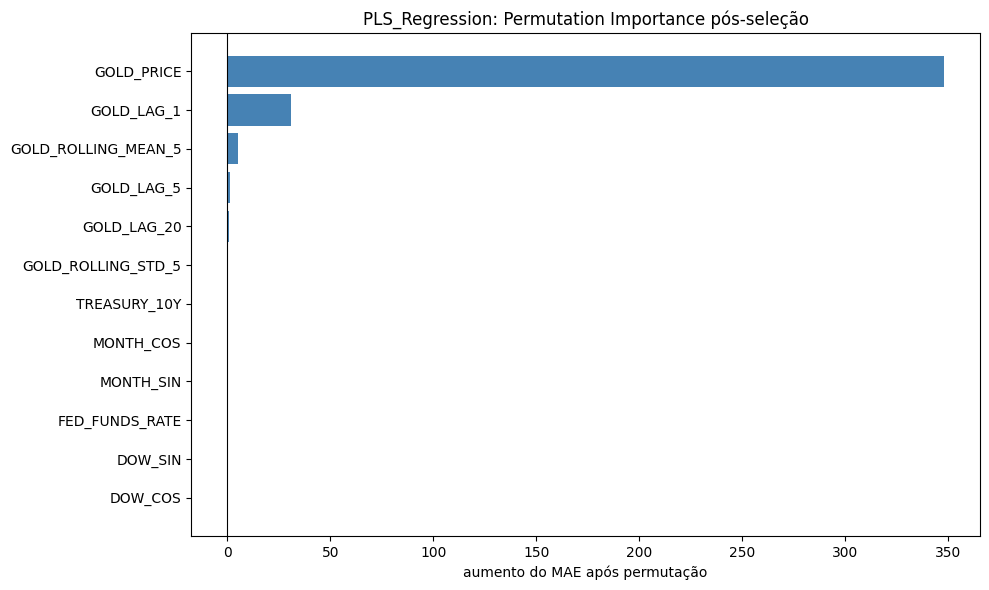

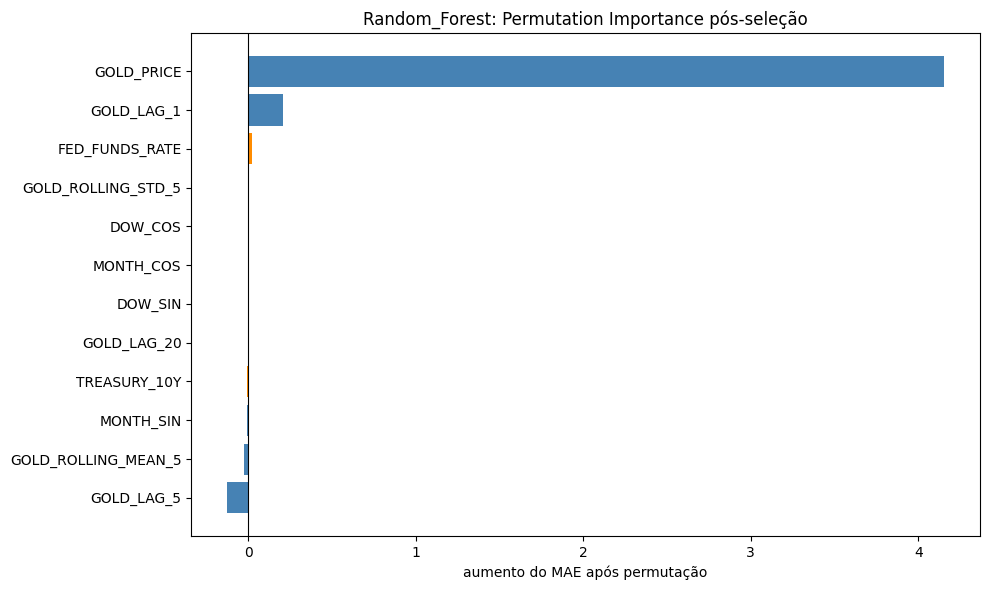

As externas foram preenchidas somente para frente e defasadas uma linha bruta. Importância preditiva não implica causalidade econômica.


In [3]:
protocol = load_protocol(require_data_decisions=True)
importance = pd.read_csv(OUT / "feature_importance.csv")

if set(importance["model"]) != {"Random_Forest", "PLS_Regression"}:
    raise RuntimeError("Faltam importâncias de Random Forest ou PLS Regression.")

importance["is_external"] = importance["feature"].isin(
    ["TREASURY_10Y", "FED_FUNDS_RATE"]
)
importance["permutation_rank"] = (
    importance.groupby("model")["permutation_mean"]
    .rank(ascending=False, method="dense")
    .astype(int)
)
importance = importance.sort_values(
    ["model", "permutation_rank", "feature"]
).reset_index(drop=True)
importance.to_csv(OUT / "feature_importance_summary.csv", index=False)
display(importance)

for model, group in importance.groupby("model"):
    ordered = group.sort_values("permutation_mean")
    colors = np.where(ordered["is_external"], "darkorange", "steelblue")
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(ordered["feature"], ordered["permutation_mean"], color=colors)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(f"{model}: Permutation Importance pós-seleção")
    ax.set_xlabel("aumento do MAE após permutação")
    plt.tight_layout()
    plt.savefig(
        OUT / f"feature_importance_{model.lower()}.png",
        dpi=150,
        bbox_inches="tight",
    )
    plt.show()

print(
    "As externas foram preenchidas somente para frente e defasadas uma linha bruta. "
    "Importância preditiva não implica causalidade econômica."
)


## Interpretação

No PLS, GOLD_PRICE, GOLD_LAG_1 e GOLD_ROLLING_MEAN_5 lideram. As externas tiveram VIP abaixo de 1; isso descreve este experimento e não implica ausência de efeito econômico geral.

## Artefatos

Arquivos usados ou produzidos nesta etapa:

- `outputs/feature_importance_summary.csv`
- `outputs/feature_importance_pls_regression.png`
- `outputs/feature_importance_random_forest.png`